In [36]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics.pairwise import cosine_similarity


[*********************100%***********************]  1 of 1 completed


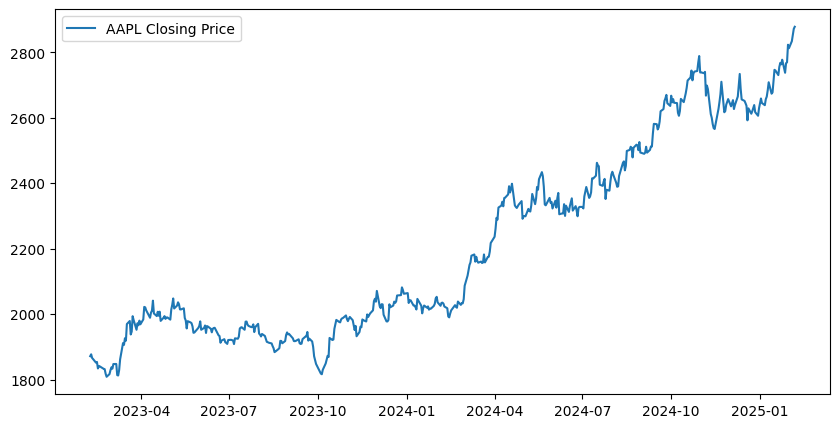

In [37]:
# Download Apple (AAPL) stock price data (last 2 years)
stock_data = yf.download('GC=F', period="2y", interval="1d")

# Calculate daily percentage change
stock_data['Return'] = stock_data['Close'].pct_change()

# Drop NaN values
stock_data.dropna(inplace=True)

# Visualize the price movement
plt.figure(figsize=(10, 5))
plt.plot(stock_data['Close'], label="AAPL Closing Price")
plt.legend()
plt.show()


In [ ]:
# Convert price movements into sequences
sequence_length = 5  # Number of days in a pattern

patterns = []
for i in range(len(stock_data) - sequence_length):
    patterns.append(stock_data['Return'].iloc[i:i + sequence_length].values)

# Convert to NumPy array
patterns = np.array(patterns)


# Normalize data (optional)
patterns = (patterns - patterns.mean()) / patterns.std()

# Reshape for LSTM (samples, time steps, features)
X_train = patterns.reshape((patterns.shape[0], patterns.shape[1], 1))


[[ 0.00294717  0.0030454  -0.00596574 -0.00182183 -0.00585142]
 [ 0.0030454  -0.00596574 -0.00182183 -0.00585142  0.00113396]
 [-0.00596574 -0.00182183 -0.00585142  0.00113396 -0.01067964]
 ...
 [ 0.01070321  0.0008313   0.01946477 -0.00371945  0.00760885]
 [ 0.0008313   0.01946477 -0.00371945  0.00760885  0.00684574]
 [ 0.01946477 -0.00371945  0.00760885  0.00684574  0.00641364]]


In [54]:
# Define LSTM model
model = Sequential([
    LSTM(50, activation='relu', input_shape=(X_train.shape[1], 1), return_sequences=False),
    Dense(10, activation='relu'),  # Reduce dimensions
    Dense(5)  # Output feature vector
])

# Compile model
model.compile(optimizer='adam', loss='mse')

# Train model (unsupervised, using data itself as labels)
model.fit(X_train, patterns, epochs=100, batch_size=16, verbose=1)

# Extract embeddings for stored patterns
historical_embeddings = model.predict(X_train)


Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.9748
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9706
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8944
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7692
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6747
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6349
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5614
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4840
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3590
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2497
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2246
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1949
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1775
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1524
Epoch 15/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1561
Epoc

In [46]:
# Fetch recent 5-day returns
live_data = yf.download('GC=F', period="7d", interval="1d" , start="2025-01-02")
live_data['Return'] = live_data['Close'].pct_change()
live_data.dropna(inplace=True)

# Get the latest 5-day sequence
current_movement = np.array([live_data['Return'].values[-sequence_length:]])

# Reshape for LSTM
current_movement_reshaped = current_movement.reshape((1, sequence_length, 1))

# Get LSTM embedding for the live sequence
current_embedding = model.predict(current_movement_reshaped)

# Compute cosine similarity between the new sequence and historical patterns
similarities = cosine_similarity(current_embedding, historical_embeddings)

# Step 1: Identify the most similar historical pattern
most_similar_index = np.argmax(similarities)
most_similar_pattern = patterns[most_similar_index]

# Step 2: Get the actual next-day return from historical data
if most_similar_index + 1 < len(stock_data) - sequence_length:
    predicted_next_move = stock_data['Return'].iloc[most_similar_index + sequence_length]
else:
    predicted_next_move = None  # If no future data available (edge case)

# Step 3: Print Results
print(f"Most similar pattern found: {most_similar_pattern}")
print(f"Similarity Score: {similarities[0, most_similar_index]:.4f}")

if predicted_next_move is not None:
    print(f"Predicted Next Day's Price Change: {predicted_next_move:.4%}")
else:
    print("Not enough data to predict the next move.")



[*********************100%***********************]  1 of 1 completed

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Most similar pattern found: [-0.9427555   1.13798987  0.05606165 -0.10346665 -0.32074939]
Similarity Score: 0.9197
Predicted Next Day's Price Change: 1.5842%


Actual Future Price: [2359.80004883]
Predicted Future Price: [2359.80004883]


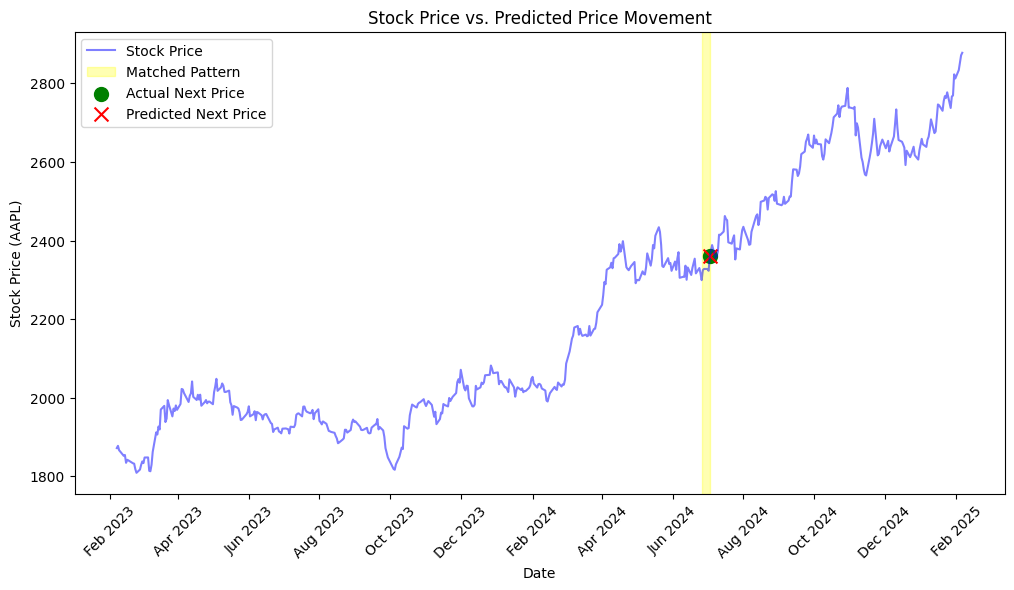

In [47]:
import matplotlib.dates as mdates

# Fetch stock closing prices for visualization
dates = stock_data.index
prices = stock_data['Close'].values

# Get dates for the most similar pattern
start_idx = most_similar_index
end_idx = most_similar_index + sequence_length

# Get future date for prediction
future_date = dates[end_idx] if end_idx < len(dates) else None
future_actual_price = prices[end_idx] if end_idx < len(prices) else None

# Predict the next price using the last known price and predicted % change
predicted_price = prices[end_idx - 1] * (1 + predicted_next_move) if predicted_next_move else None

# Plot stock price movement
plt.figure(figsize=(12, 6))
plt.plot(dates, prices, label="Stock Price", color='blue', alpha=0.5)
plt.axvspan(dates[start_idx], dates[end_idx], color='yellow', alpha=0.3, label="Matched Pattern")

# Mark actual next move if available
if future_date:
    plt.scatter(future_date, future_actual_price, color='green', marker='o', s=100, label="Actual Next Price")

# Mark predicted next price
if predicted_price:
    plt.scatter(future_date, predicted_price, color='red', marker='x', s=100, label="Predicted Next Price")
    

print(f"Actual Future Price: {future_actual_price}")
print(f"Predicted Future Price: {predicted_price}")


# Formatting
plt.xlabel("Date")
plt.ylabel("Stock Price (AAPL)")
plt.title("Stock Price vs. Predicted Price Movement")
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# Show plot
plt.show()
